# Categorical plot hands-on
<img src="https://s3.amazonaws.com/assets.liffafi.com/wp-content/uploads/2025/10/24003625/marve-1.webp">

In this hands-on, we will use the Marvel dataset to practice using different plots to visualize distributions of values between groups. You are free to come up with you own questions and use one of the categorical plots to help answer each question. You are also free to build your own dataframe that contains a specific subset of the data to help you answer your questions.

The dataset is in https://raw.githubusercontent.com/csbfx/advpy122-data/master/marvel-wikia-data.csv

Data source: https://github.com/fivethirtyeight/data/tree/master/comic-characters

| Variable |	Definition |
| :------- | :-
|page_id|	The unique identifier for that characters page within the wikia
|name|	The name of the character
|urlslug|	The unique url within the wikia that takes you to the character
|ID|	The identity status of the character (Secret Identity, Public identity, [on marvel only: No Dual Identity])
|ALIGN|	If the character is Good, Bad or Neutral
|EYE|	Eye color of the character
|HAIR|	Hair color of the character
|SEX|	Sex of the character (e.g. Male, Female, etc.)
|GSM|	If the character is a gender or sexual minority (e.g. Homosexual characters, bisexual characters)
|ALIVE|	If the character is alive or deceased
|APPEARANCES|	The number of appareances of the character in comic books (as of Sep. 2, 2014. Number will become increasingly out of date as time goes on.)
|FIRST APPEARANCE|	The month and year of the character's first appearance in a comic book, if available
|YEAR|	The year of the character's first appearance in a comic book, if available

## Q1. How big is this dataset?
Use pandas to find out the number of rows and columns.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

marvel_url = 'https://raw.githubusercontent.com/csbfx/advpy122-data/master/marvel-wikia-data.csv'
marvel = pd.read_csv(marvel_url)
print(f'The dataset contains {marvel.shape[0]:,} rows and {marvel.shape[1]} columns.')
display(marvel.head())


The dataset contains 16,376 rows and 13 columns.


,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,Year
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,NaN,Living Characters,4043.0,Aug-62,1962.0
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,NaN,Living Characters,3360.0,Mar-41,1941.0
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,3061.0,Oct-74,1974.0
3,1868,"Iron Man (Anthony \""Tony\"" Stark)",\/Iron_Man_(Anthony_%22Tony%22_Stark),Public Identity,Good Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,2961.0,Mar-63,1963.0
4,2460,Thor (Thor Odinson),\/Thor_(Thor_Odinson),No Dual Identity,Good Characters,Blue Eyes,Blond Hair,Male Characters,NaN,Living Characters,2258.0,Nov-50,1950.0


## Q2. Strip plots
Come up with a question using this dataset and use a `strip` plot to help answer the question. State your question in a markdown cell. Recall that a `strip` plot is a categorical plot where one axis is category and the other is a continuous variable. Set the appropriate arguments to make the plot more readable. Be sure to include a meaning title for the plot.

**Question:** How do positive recorded comic-appearance counts differ among good, bad, and neutral characters?


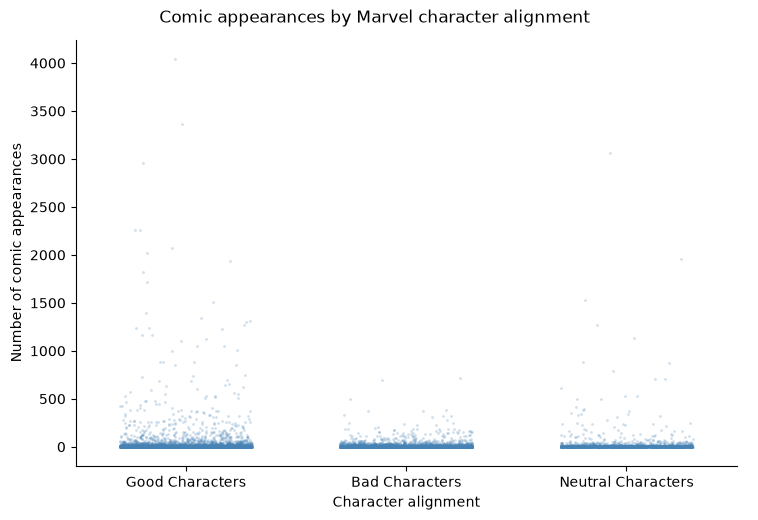

In [2]:
alignment_order = ['Good Characters', 'Bad Characters', 'Neutral Characters']
appearances = marvel.loc[
    marvel['ALIGN'].isin(alignment_order) & (marvel['APPEARANCES'] > 0)
].copy()

g = sns.catplot(data=appearances, x='ALIGN', y='APPEARANCES', kind='strip',
                order=alignment_order, jitter=0.3, alpha=0.25, size=2,
                color='steelblue', height=5, aspect=1.5)
g.set_axis_labels('Character alignment', 'Number of comic appearances')
g.fig.suptitle('Comic appearances by Marvel character alignment', y=1.03)
plt.show()


## Q3. Multiples of Strip plots
Come up with a question using this dataset and use a strip plot that contains multiples (splitting the plot into multiples by a category that has two or more unique values) by using the `row` or `col` argument. State your question in a markdown cell. Recall that a strip plot is a categorical plot where one axis is category and the other is a continuous variable. Set the appropriate arguments to make the plot more readable. Be sure to include a meaning title for the plot.

**Question:** Among characters introduced in 1980 or later, how do debut years vary across secret, public, and no-dual-identity groups, separately for male and female characters?


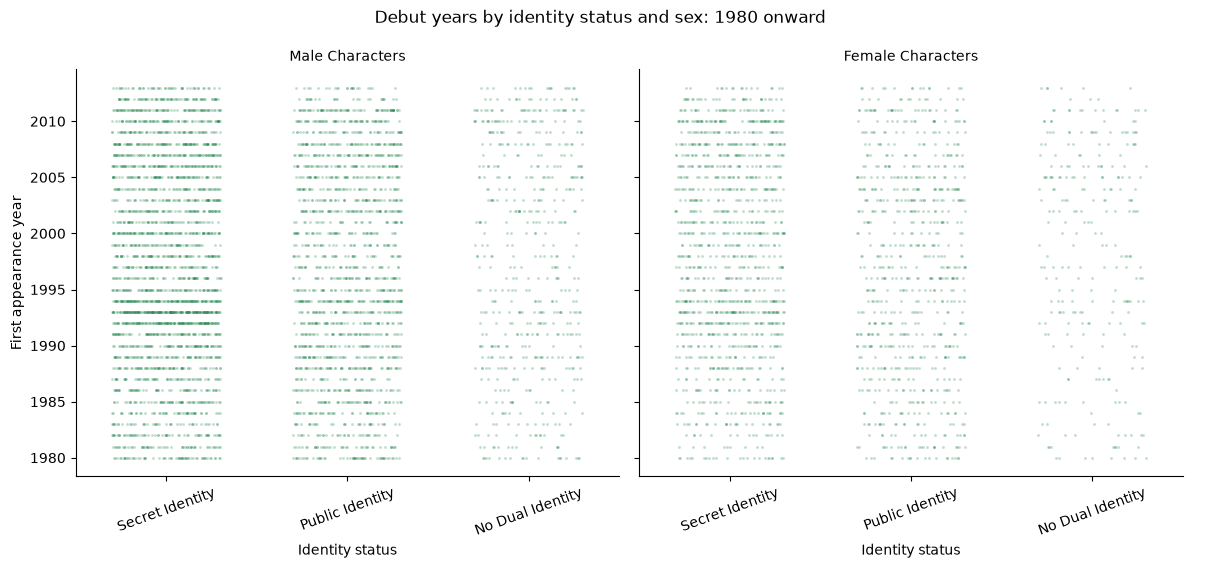

In [3]:
identity_order = ['Secret Identity', 'Public Identity', 'No Dual Identity']
sex_order = ['Male Characters', 'Female Characters']
modern_identities = marvel.loc[
    (marvel['Year'] >= 1980)
    & marvel['ID'].isin(identity_order)
    & marvel['SEX'].isin(sex_order)
].copy()
g = sns.catplot(data=modern_identities, x='ID', y='Year',
                col='SEX', col_order=sex_order, kind='strip',
                order=identity_order, jitter=0.3, alpha=0.3, size=2,
                color='seagreen', height=5, aspect=1.2)
g.set_axis_labels('Identity status', 'First appearance year')
g.set_titles('{col_name}')
g.set_xticklabels(rotation=20)
g.fig.suptitle('Debut years by identity status and sex: 1980 onward', y=1.05)
plt.show()


## Q4. Swarm plot
Come up with a question using this dataset and use a `swarm` plot to help answer the question. State your question in a markdown cell. Recall that a `swarm` plot is also a categorical plot where one axis is category and the other is a continuous variable. Set the appropriate arguments to make the plot more readable. Be sure to include a meaning title for the plot.

**Question:** For characters introduced in 2000 or later, how do individual appearance counts compare among characters with blue, brown, green, and black eyes?


c:\Users\hurri\anaconda3\envs\cs133\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 20.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\hurri\anaconda3\envs\cs133\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 25.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


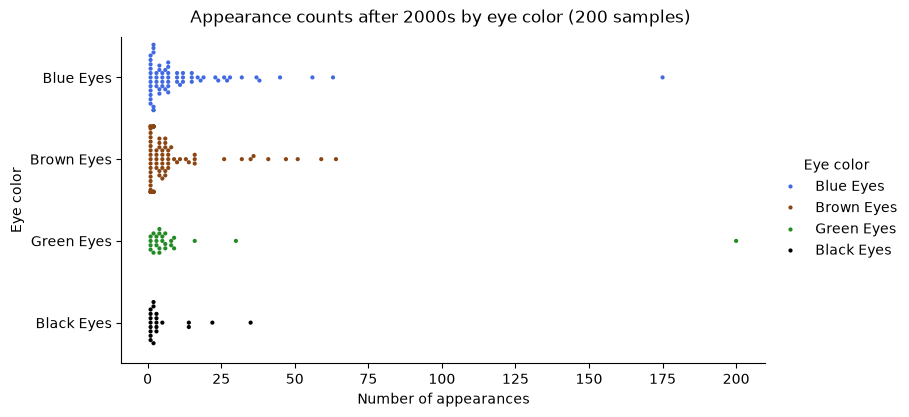

In [11]:
eye_order = ['Blue Eyes', 'Brown Eyes', 'Green Eyes', 'Black Eyes']
eye_palette = {
    'Blue Eyes': 'royalblue',
    'Brown Eyes': 'saddlebrown',
    'Green Eyes': 'forestgreen',
    'Black Eyes': 'black'
}

recent_eyes = marvel.loc[
    (marvel['Year'] >= 2000)
    & marvel['EYE'].isin(eye_order)
].copy()

eye_sample = recent_eyes.sample(n=200, random_state=1)

g = sns.catplot(
    data=eye_sample, x='APPEARANCES', y='EYE', kind='swarm',
    hue='EYE', palette=eye_palette, hue_order=eye_order,
    order=eye_order, dodge=False, legend='full',
    size=3, height=4, aspect=2
)

g.legend.set_title('Eye color')
g.set_axis_labels('Number of appearances', 'Eye color')
g.fig.suptitle('Appearance counts after 2000s by eye color (200 samples)', y=1.03)
plt.show()

## Q5. Box plots
Box plot is one of the most commonly used plot for visualizing data distribution. We can convert the `swamp` plot into a `box` plot by simply changing the kind argument to `kind="box"`. Convert the swarm plot that you created in Q4 with a boxplot here. Set the appropriate arguments to make the plot more readable. Be sure to include a meaning title for the plot.

**Question:** In the same Q4 sample, which eye-color group has the highest median appearance count, and which has the widest middle 50% of counts?


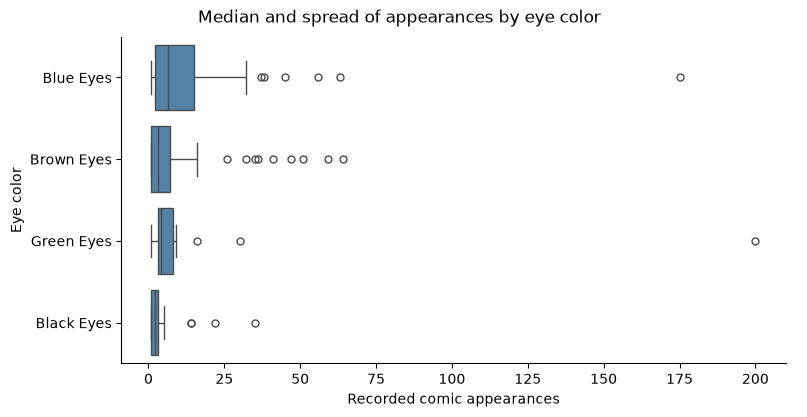

In [5]:
g = sns.catplot(data=eye_sample, x='APPEARANCES', y='EYE', kind='box',
                order=eye_order, color='steelblue', height=4, aspect=2)
g.set_axis_labels('Recorded comic appearances', 'Eye color')
g.fig.suptitle('Median and spread of appearances by eye color', y=1.03)
plt.show()


## Q6. Violin plots
Come up with a question using this dataset and use a `violin` plot to help answer the question. State your question in a markdown cell. Recall that a `violin` plot is also a categorical plot where one axis is category and the other is a continuous variable. Set the appropriate arguments to make the plot more readable. You might want to set setting `cut` to zero if the distribution spreads beyond the values of the data in the dataset. Be sure to include a meaning title for the plot.

**Question:** Among characters introduced before 1980, how do the shapes and concentrations of debut-year distributions differ for black, brown, blond, red, and white hair?


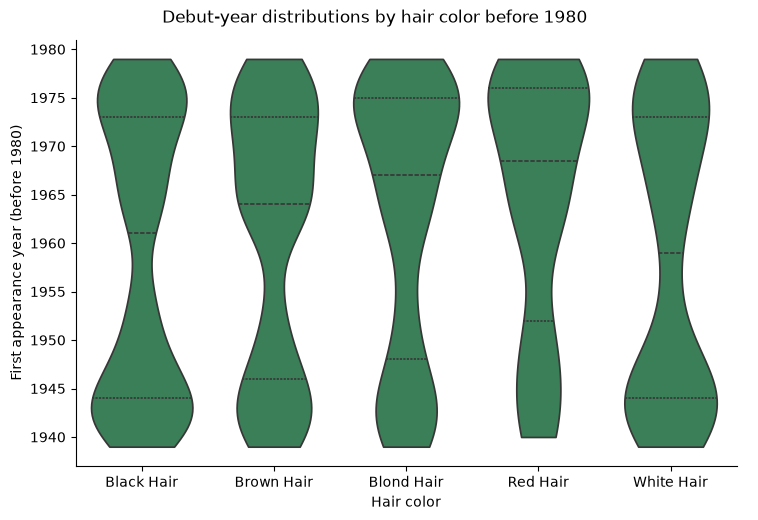

In [6]:
hair_order = ['Black Hair', 'Brown Hair', 'Blond Hair', 'Red Hair', 'White Hair']
early_hair = marvel.loc[
    (marvel['Year'] < 1980) & marvel['HAIR'].isin(hair_order)
].copy()
g = sns.catplot(data=early_hair, x='HAIR', y='Year', kind='violin',
                order=hair_order, cut=0, inner='quartile', color='seagreen',
                height=5, aspect=1.5)
g.set_axis_labels('Hair color', 'First appearance year (before 1980)')
g.fig.suptitle('Debut-year distributions by hair color before 1980', y=1.03)
plt.show()


## Bonus:
Because violin plots are symetrical, when we have only two categories we can put one on each side with `split = True`. Try to create a violin plot using the `split` parameter. You will need to come up with a dataframe using this dataset with data that has two categories.

**Question:** For characters introduced in the 1990s with recorded comic appearances, how do appearance-count distributions differ between living and deceased characters, and does that pattern differ for male and female characters?


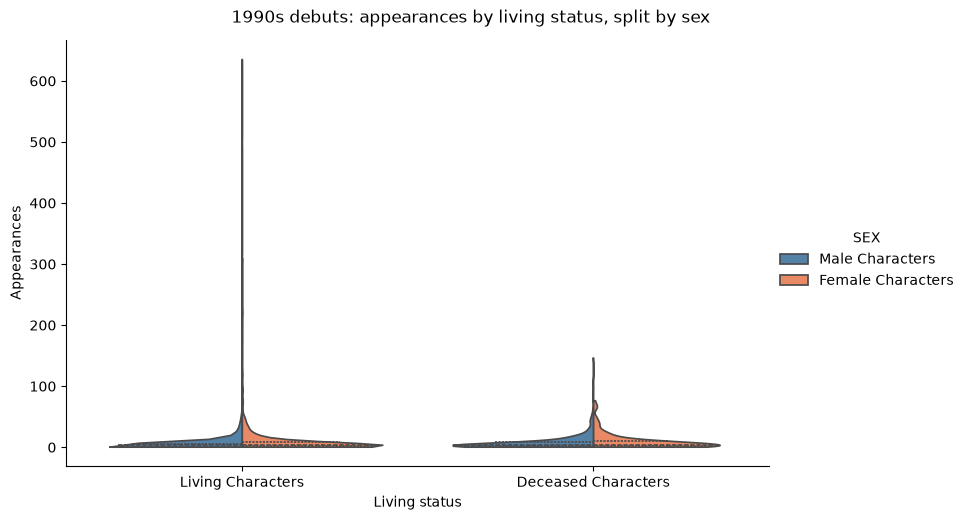

In [7]:
alive_order = ['Living Characters', 'Deceased Characters']
split_sex_order = ['Male Characters', 'Female Characters']
nineties_status = marvel.loc[
    marvel['Year'].between(1990, 1999)
    & marvel['ALIVE'].isin(alive_order)
    & marvel['SEX'].isin(split_sex_order)
].copy()
g = sns.catplot(data=nineties_status, x='ALIVE', y='APPEARANCES', hue='SEX',
                order=alive_order, hue_order=split_sex_order, kind='violin',
                split=True, cut=0, inner='quartile',
                palette=['steelblue', 'coral'], height=5, aspect=1.6)
g.set_axis_labels('Living status', 'Appearances')
g.fig.suptitle('1990s debuts: appearances by living status, split by sex', y=1.03)
plt.show()
